# Langevin versus diffusion — reproducibility archive for the thesis: "Mathematical Foundations of Diffusion-Based Generative Modeling"

This notebook is a **self-contained computational archive** for three two-dimensional comparison
experiments. It generates every dataset synthetically, trains every network locally on CPU and
evaluates every sampler against a known population construction. No external data file or
pretrained checkpoint is required.



## Contents

1. **Experiment 1 — learned scores from the same finite dataset.** A reverse VP-SDE and an
   unadjusted Langevin sampler both use information derived from one fixed sample of 1,500 points.
   The notebook records mode frequencies, density-based and sample-based metrics, score diagnostics,
   a terminal denoising step and an initialization ablation.
2. **Experiment 2 — a Gaussian-smoothed empirical score on a thin annulus.** The same Langevin
   implementation is run with an analytic annular vector field and with exact Gaussian-KDE scores
   based on 40 or 400 observations. A network is also trained on the 40-point dataset, and a
   thickness and training-duration study is retained.
3. **Experiment 3 — analytic-score comparison.** Plain Langevin uses the exact score of the target
   at time zero, while the reverse VP-SDE uses the exact family of noised scores along its annealing
   path for a 14-component concentric-ring mixture.

## How to reproduce the archived outputs

1. Use the package versions recorded below, or record any replacements in a derived archive.
2. Start a fresh Python kernel.
3. Execute **all cells once, in order**, without inserting, deleting or selectively rerunning a cell.
4. Keep the two initial seeds equal to zero. The notebook uses a single global random stream, so
   changing the order of any stochastic operation changes all later numerical values.

Approximate runtime is hardware-dependent; the notebook was designed for CPU execution. Memory use
is dominated by dense pairwise-distance matrices in the KDE and MMD calculations.


### Recorded dependency baseline

The supplied notebook metadata records Python 3.8.8. The source environment available with the
notebook contained the following distributions:

| Dependency | Recorded version |
|---|---:|
| Python | 3.8.8 |
| NumPy | 1.23.5 |
| PyTorch | 2.4.1+cpu |
| Matplotlib | 3.3.4 |

Only `math`, `time`, NumPy, PyTorch and Matplotlib are required. The next non-stochastic cell prints
the environment that actually executes the archive. Version changes can alter floating-point
values and random streams, even when the seed is unchanged.


In [1]:
# Ensure that figures are embedded in the notebook during non-interactive Run All execution.
_archive_ipython = get_ipython()
if _archive_ipython is not None:
    _archive_ipython.run_line_magic("matplotlib", "inline")


In [2]:
# ============================================================
# Imports and configuration
# ============================================================
import math
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

device = torch.device("cpu")
torch.manual_seed(0)
np.random.seed(0)

In [3]:
# Reproducibility environment record (does not consume random numbers).
import platform
import sys
import matplotlib

print("Python:", sys.version.replace("\n", " "))
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Matplotlib backend:", matplotlib.get_backend())
print("PyTorch default dtype:", torch.get_default_dtype())
print("PyTorch CPU threads:", torch.get_num_threads())
print("Requested device:", device)


Python: 3.8.8 (default, Apr 13 2021, 15:08:03) [MSC v.1916 64 bit (AMD64)]
Platform: Windows-10-10.0.26100-SP0
NumPy: 1.23.5
PyTorch: 2.4.1+cpu
Matplotlib: 3.3.4
Matplotlib backend: module://ipykernel.pylab.backend_inline
PyTorch default dtype: torch.float32
PyTorch CPU threads: 6
Requested device: cpu


### Randomness and execution order

`torch.manual_seed(0)` and `np.random.seed(0)` are each called once in the preceding original setup
cell. Python's `random` module is not used. Datasets, mini-batches, forward noises, sampler noises and
sliced-Wasserstein directions all consume the global generator state. Consequently, numerical
reproduction means **Restart Kernel and Run All once**; selective re-execution is a different run.

The device is fixed to CPU. No call to `torch.use_deterministic_algorithms(True)` is made, and CPU
thread/BLAS behavior is environment-dependent. Seeded equality is therefore expected within the
recorded environment but is not a cross-platform bitwise guarantee.


## Setup — eight-component anisotropic Gaussian-mixture target

All target distributions in this notebook live in \(\mathbb R^2\), and \(\mathcal N(m,\Sigma)\)
denotes a density with respect to two-dimensional Lebesgue measure. For \(k=0,\ldots,7\), define

\[
\theta_k=\frac{2\pi k}{8},\qquad
u_{r,k}=(\cos\theta_k,\sin\theta_k)^\top,\qquad
u_{\tau,k}=(-\sin\theta_k,\cos\theta_k)^\top.
\]

Experiment 1 uses

\[
p_0(x)=\sum_{k=0}^{7}w_k\,\mathcal N(x;m_k,\Sigma_k),
\]

with

\[
m_k=1.5\,u_{r,k},\qquad
\Sigma_k=0.05^2u_{r,k}u_{r,k}^{\top}+0.12^2u_{\tau,k}u_{\tau,k}^{\top},
\]

and

\[
(w_0,\ldots,w_7)=\frac1{27}(8,1,5,1,6,1,4,1).
\]

`sample_ring(n)` first samples the component index from this categorical distribution and then
adds independent Gaussian perturbations of standard deviations \(0.05\) and \(0.12\) in the
radial and tangential directions. Thus the population target used for sampling and likelihood
evaluation is fully normalized and known.


In [4]:
# ============================================================
# Ring of anisotropic Gaussians.
# ============================================================
n_modes = 8
R = 1.5
sigma_r = 0.05
sigma_t = 0.12

angles = torch.linspace(0, 2 * math.pi, n_modes + 1)[:-1]
means = R * torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)          # (K, 2)
u_r = torch.stack([torch.cos(angles),  torch.sin(angles)], dim=1)
u_t = torch.stack([-torch.sin(angles), torch.cos(angles)], dim=1)
covs = (sigma_r ** 2) * (u_r[:, :, None] * u_r[:, None, :]) \
     + (sigma_t ** 2) * (u_t[:, :, None] * u_t[:, None, :])                      # (K, 2, 2)
raw_w = torch.tensor([8., 1., 5., 1., 6., 1., 4., 1.])
weights = raw_w / raw_w.sum()

lim = R + 6 * max(sigma_t, sigma_r) + 0.3          # plotting limits, defined once


def sample_ring(n):
    comp = torch.multinomial(weights, n, replacement=True)
    a = angles[comp]
    ur = torch.stack([torch.cos(a),  torch.sin(a)], dim=1)
    ut = torch.stack([-torch.sin(a), torch.cos(a)], dim=1)
    er = torch.randn(n) * sigma_r
    et = torch.randn(n) * sigma_t
    return R * ur + er[:, None] * ur + et[:, None] * ut

## Setup — analytic Gaussian-mixture density and score

For a general Gaussian mixture

\[
p(x)=\sum_{k=1}^K w_k\,\mathcal N(x;m_k,\Sigma_k),
\]

let

\[
\gamma_k(x)=
\frac{w_k\mathcal N(x;m_k,\Sigma_k)}
     {\sum_{\ell=1}^K w_\ell\mathcal N(x;m_\ell,\Sigma_\ell)}
\]

be the posterior responsibility of component \(k\). The exact population score used below is

\[
\nabla\log p(x)
=-\sum_{k=1}^K\gamma_k(x)\Sigma_k^{-1}(x-m_k).
\]

The implementation evaluates log densities with `logsumexp` and checks the analytic score against
automatic differentiation at five randomly generated points. Computations use PyTorch's default
floating-point dtype (`float32` in the archived environment), so this check is numerical rather
than a symbolic identity test.


In [5]:
# ============================================================
# Analytic log-density and score of a Gaussian mixture (full covariance).
# ============================================================
def gmm_log_prob_and_score(x, weights, means, covs):
    D = x.shape[1]
    cov_inv = torch.linalg.inv(covs)
    logdet = torch.logdet(covs)
    diff = x[:, None, :] - means[None, :, :]
    sol = torch.einsum("kij,nkj->nki", cov_inv, diff)
    maha = (diff * sol).sum(-1)
    log_norm = -0.5 * maha - 0.5 * (D * math.log(2 * math.pi) + logdet)[None, :]
    log_joint = torch.log(weights)[None, :] + log_norm
    log_prob = torch.logsumexp(log_joint, dim=1)
    resp = torch.softmax(log_joint, dim=1)
    score = -(resp[..., None] * sol).sum(1)
    return log_prob, score

# Sanity check against autograd.
x_chk = torch.randn(5, 2, requires_grad=True)
lp, s_a = gmm_log_prob_and_score(x_chk, weights, means, covs)
print("max |analytic - autograd| =",
      (s_a - torch.autograd.grad(lp.sum(), x_chk)[0]).abs().max().item())

max |analytic - autograd| = 0.0003662109375


## Setup — VP-SDE, score network and denoising score matching

### Forward process

The learned diffusion experiments use the variance-preserving SDE

\[
dX_t=-\frac12\beta(t)X_t\,dt+\sqrt{\beta(t)}\,dW_t,
\qquad \beta(t)=0.1+19.9t,\qquad t\in[0,1].
\]

Writing

\[
B(t)=\int_0^t\beta(s)\,ds=0.1t+9.95t^2,
\qquad \mu_t=e^{-B(t)/2},\qquad v_t=1-e^{-B(t)},
\]

the transition kernel is

\[
X_t\mid X_0=x_0\sim\mathcal N(\mu_t x_0,v_tI_2).
\]

At \(t=1\), \(\mu_1\simeq0.0065716\) and \(v_1\simeq0.9999568\), which motivates the
implemented terminal approximation \(X_1\sim\mathcal N(0,I_2)\).

### Network

The score network maps \((x,t)\in\mathbb R^2\times[0,1]\) to \(\mathbb R^2\). Time is encoded by

\[
\psi(t)=\bigl(\sin(2\pi jt),\cos(2\pi jt)\bigr)_{j=1}^{16}\in\mathbb R^{32}.
\]

The architecture is

\[
34\longrightarrow128\longrightarrow128\longrightarrow128\longrightarrow2,
\]

with SiLU after each hidden affine layer and no output activation. It contains 37,762 trainable
parameters. No normalization, dropout or explicit regularizer is used.

### Implemented DSM objective

Each mini-batch observation is sampled with replacement from the fixed dataset. Independently for
each observation,

\[
t\sim\operatorname{Unif}[10^{-4},1),\qquad
X_t=\mu_tX_0+\sqrt{v_t}Z,\qquad Z\sim\mathcal N(0,I_2).
\]

The conditional perturbation score is

\[
\nabla_{x_t}\log p(x_t\mid x_0)=-\frac{x_t-\mu_tx_0}{v_t}.
\]

For batch size \(M\), the code minimizes

\[
\widehat{\mathcal L}(\theta)
=\frac1{2M}\sum_{i=1}^{M}v_{t_i}
\left\|s_\theta(X_{t_i},t_i)+\frac{X_{t_i}-\mu_{t_i}X_{0,i}}{v_{t_i}}\right\|_2^2.
\]

The factor \(1/2\) comes from averaging the two output coordinates. Optimization uses Adam with
learning rate \(10^{-3}\) and PyTorch defaults
`betas=(0.9, 0.999)`, `eps=1e-8`, `weight_decay=0`, `amsgrad=False`. There is no learning-rate
schedule, gradient clipping, validation set or early stopping. After every update, an exponential
moving average is updated as

\[
\bar\theta_n=0.999\bar\theta_{n-1}+0.001\theta_n,
\qquad \bar\theta_0=\theta_0.
\]

All learned reverse-SDE samples use the EMA parameters. There is no EMA bias correction or warm-up.


In [6]:
# ============================================================
# Score network and VP-SDE denoising score-matching loss.
# ============================================================
class ScoreMLP(torch.nn.Module):
    def __init__(self, dim=2, hidden=128, n_freq=16):
        super().__init__()
        self.register_buffer("freqs", 2 * math.pi * torch.arange(1, n_freq + 1).float())
        self.net = torch.nn.Sequential(
            torch.nn.Linear(dim + 2 * n_freq, hidden), torch.nn.SiLU(),
            torch.nn.Linear(hidden, hidden),           torch.nn.SiLU(),
            torch.nn.Linear(hidden, hidden),           torch.nn.SiLU(),
            torch.nn.Linear(hidden, dim),
        )
    def forward(self, x, t):
        te = t * self.freqs
        emb = torch.cat([torch.sin(te), torch.cos(te)], dim=-1)
        return self.net(torch.cat([x, emb], dim=-1))


def calc_loss(net, x):
    t = torch.rand((x.shape[0], 1), device=x.device) * (1 - 1e-4) + 1e-4
    int_beta = (0.1 + 0.5 * (20 - 0.1) * t) * t
    mu_t = x * torch.exp(-0.5 * int_beta)
    var_t = -torch.expm1(-int_beta)
    x_t = torch.randn_like(x) * var_t ** 0.5 + mu_t
    grad_log_p = -(x_t - mu_t) / var_t
    return (var_t * (net(x_t, t) - grad_log_p) ** 2).mean()


def train_diffusion(data, n_steps=5000, batch=512, lr=1e-3, ema_decay=0.999, log_every=1000):
    """Train a ScoreMLP on a FIXED dataset by DSM; return the EMA network."""
    net = ScoreMLP().to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    ema = {k: v.clone() for k, v in net.state_dict().items()}
    N = data.shape[0]
    t0 = time.time()
    for step in range(n_steps):
        x = data[torch.randint(0, N, (min(batch, N),))]
        opt.zero_grad(); loss = calc_loss(net, x); loss.backward(); opt.step()
        with torch.no_grad():                          # EMA update
            for k, v in net.state_dict().items():
                ema[k].mul_(ema_decay).add_(v, alpha=1 - ema_decay)
        if step % log_every == 0:
            print(f"  step {step:5d} ({time.time()-t0:5.1f}s) loss {loss.item():.4f}")
    ema_net = ScoreMLP().to(device)
    ema_net.load_state_dict(ema)
    print(f"  trained in {time.time()-t0:.1f}s (sampling uses the EMA weights)")
    return ema_net

### Training budgets used later

| Training run | Dataset size | Updates | Requested batch | Effective batch | Data-index draws | Learning rate | EMA |
|---|---:|---:|---:|---:|---:|---:|---:|
| Experiment 1 | 1,500 | 10,000 | 512 | 512 | 5,120,000 | \(10^{-3}\) | 0.999 |
| Experiment 2, 40-point model | 40 | 3,000 | 64 | 40 | 120,000 | \(10^{-3}\) | 0.999 |
| Experiment 2, checkpoint trajectory | 40 | 32,000 cumulative | 40 | 40 | 1,280,000 | \(10^{-3}\) | 0.999 |

An “update” means one Adam optimizer step after one newly sampled mini-batch and one newly sampled
time/noise pair per observation. No epoch convention is used because sampling is with replacement.


In [7]:
# ============================================================
# Samplers.
#   generate_samples : reverse-time VP-SDE + final Tweedie step
#   langevin_fn      : plain Langevin for ANY score function
#   kde_score        : empirical (kernel) score of a dataset at bandwidth h
#   empirical_score_t: exact score of the NOISED empirical distribution p̂_t
# ============================================================
@torch.no_grad()
def generate_samples(net, nsamples, n_steps=2000, t_min=0.02, tweedie=True):
    x = torch.randn(nsamples, 2, device=device)
    ts = torch.linspace(1, max(t_min, 1e-3), n_steps, device=device)
    beta = lambda t: 0.1 + (20 - 0.1) * t
    for i in range(len(ts) - 1):
        t = ts[i]; dt = ts[i + 1] - t
        g = beta(t) ** 0.5
        drift = -0.5 * beta(t) * x - g * g * net(x, t.expand(x.shape[0], 1))
        x = x + drift * dt + g * torch.randn_like(x) * torch.abs(dt) ** 0.5
    if tweedie:                                       # E[x_0 | x_{t_min}]: removes residual noise
        tm = float(ts[-1])
        ib = (0.1 + 0.5 * (20 - 0.1) * tm) * tm
        mu_t, var_t = math.exp(-0.5 * ib), 1 - math.exp(-ib)
        score = net(x, torch.full((nsamples, 1), tm, device=device))
        x = (x + var_t * score) / mu_t
    return x


def langevin_fn(score_fn, n, n_steps=2000, step=5e-4, init_std=1.5):
    x = torch.randn(n, 2) * init_std
    for _ in range(n_steps):
        x = x + 0.5 * step * score_fn(x) + math.sqrt(step) * torch.randn_like(x)
    return x


def kde_score(x, data, h):
    """Score of the KDE (1/N) sum_i N(x; data_i, h^2 I): the memorization limit."""
    d2 = torch.cdist(x, data) ** 2
    w = torch.softmax(-d2 / (2 * h ** 2), dim=1)
    return (w @ data - x) / h ** 2


def empirical_score_t(x, data, t):
    """Exact score of p̂_t: mixture of N isotropic Gaussians at mu_t * data_i, var var_t."""
    ib = (0.1 + 0.5 * (20 - 0.1) * t) * t
    mu_t, var_t = math.exp(-0.5 * ib), 1 - math.exp(-ib)
    c = mu_t * data
    d2 = torch.cdist(x, c) ** 2
    w = torch.softmax(-d2 / (2 * var_t), dim=1)
    return (w @ c - x) / var_t

### Sampler definitions

#### Learned reverse VP-SDE

For a decreasing uniform grid \(1=t_0>\cdots>t_{L-1}=t_*\), the code uses

\[
X_{j+1}=X_j+
\left[-\tfrac12\beta(t_j)X_j-\beta(t_j)s_\theta(X_j,t_j)\right]\Delta t_j
+\sqrt{\beta(t_j)|\Delta t_j|}\,\xi_j,
\]

where \(\Delta t_j=t_{j+1}-t_j<0\) and \(\xi_j\sim\mathcal N(0,I_2)\). The argument
`n_steps=L` counts grid points, so the function performs \(L-1\) Euler–Maruyama updates. There is no
corrector or adaptive solver. When enabled, one additional network evaluation is used by the final
Tweedie map.

#### Unadjusted Langevin algorithm

For a supplied vector field \(s\),

\[
X_{k+1}=X_k+\frac h2s(X_k)+\sqrt h\,\xi_k,
\qquad \xi_k\sim\mathcal N(0,I_2).
\]

This is the unadjusted Euler discretization of
\(dX_\tau=\frac12s(X_\tau)d\tau+dB_\tau\). There is no Metropolis acceptance step. Every displayed
point is the endpoint of an independently initialized chain; there is no separate burn-in removal,
thinning or pooling of intermediate states. At nonzero step size, the invariant law of the
discretized chain, when it exists, is generally not exactly the continuous-time target.

#### Gaussian-KDE score

For data \(\mathcal D=\{x^{(1)},\ldots,x^{(N)}\}\) and bandwidth \(b\),

\[
\widehat p_b(x)=\frac1N\sum_i\mathcal N(x;x^{(i)},b^2I_2),
\qquad
\nabla\log\widehat p_b(x)=
\frac{\sum_i\omega_i(x)x^{(i)}-x}{b^2},
\]

with \(\omega_i(x)\propto\exp[-\|x-x^{(i)}\|_2^2/(2b^2)]\). The implementation computes all
pairwise distances densely and performs no batching.


## Setup — evaluation metrics and diagnostics

Every reported quantity is a finite-sample statistic. Generated samples are denoted
\(Y_1,\ldots,Y_M\); reference samples are generated independently from the known population
construction unless stated otherwise.

### Nearest-centre mode frequencies and `weight-TV`

Each generated point is assigned to the nearest listed component centre,

\[
A(y)=\operatorname*{argmin}_{k}\|y-m_k\|_2,
\qquad
\widehat f_k=\frac1M\sum_{i=1}^{M}\mathbf 1_{\{A(Y_i)=k\}}.
\]

The reported statistic is

\[
D_{\mathrm{mode}}=\frac12\sum_k|\widehat f_k-w_k|.
\]

Despite the printed label `weight-TV`, this is total variation between two categorical vectors,
not total variation between the full probability measures on \(\mathbb R^2\). It also treats
nearest-centre assignments as component labels; this is accurate only to the extent that the
components are sufficiently separated.

### Mean target log likelihood

For a known normalized GMM density \(p\),

\[
\operatorname{MLL}=\frac1M\sum_{i=1}^{M}\log p(Y_i),
\]

using the natural logarithm. This is a density diagnostic, not a divergence: concentration near
density maxima can increase it even when mode frequencies are incorrect.

### RBF MMD estimator

For generated points \(X_1,\ldots,X_m\) and reference points \(Y_1,\ldots,Y_n\), set

\[
\ell^2=\operatorname{median}_{i,j}\|X_i-Y_j\|_2^2,
\qquad
k(x,y)=\exp\!\left[-\frac{\|x-y\|_2^2}{2\ell^2}\right].
\]

The code reports the off-diagonal unbiased U-statistic

\[
\widehat{\operatorname{MMD}}_u^2
=\frac{\sum_{i\ne i'}k(X_i,X_{i'})}{m(m-1)}
+\frac{\sum_{j\ne j'}k(Y_j,Y_{j'})}{n(n-1)}
-\frac{2}{mn}\sum_{i,j}k(X_i,Y_j).
\]

This estimator can be negative at finite sample size. Its bandwidth is recomputed independently
for each generated/reference pair.

### Monte-Carlo sliced Wasserstein statistic

For every call, the code draws 128 independent directions
\(\Theta_\ell=G_\ell/\|G_\ell\|_2\), with \(G_\ell\sim\mathcal N(0,I_2)\). Generated and
reference samples must have the same size. Sorting each projected sample gives

\[
\widehat{\operatorname{SW}}_2^2
=\frac1{128M}\sum_{\ell=1}^{128}\sum_{i=1}^{M}
\left(X_{(i)}^{(\ell)}-Y_{(i)}^{(\ell)}\right)^2.
\]

The output label `sliced-W2` therefore denotes an estimate of **squared** sliced Wasserstein
distance. Fresh projection directions are drawn for each method call.

### Median nearest-training-point distance

\[
D_{\mathrm{NN}}(Y,\mathcal D)
=\operatorname{median}_{i}\min_{x\in\mathcal D}\|Y_i-x\|_2.
\]

The truth baseline applies the same statistic to an independent population sample. This is an
operational memorization probe, not a probability metric. Values computed against datasets of
different sizes, such as \(N=40\) and \(N=400\), are not directly comparable without accounting
for the changed nearest-neighbour baseline.

### Radial standard deviation

The code retains points satisfying

\[
R-0.5<\|Y_i\|_2<R+0.5
\]

and reports PyTorch's Bessel-corrected sample standard deviation of their radii. It is only an
approximate proxy for the radial component standard deviation \(\sigma_r\).


In [8]:
# ============================================================
# Metric zoo. (down)=smaller better, (up)=larger better.
# ============================================================
def mode_fractions(pts, centers):
    d = torch.cdist(pts, centers)
    counts = torch.bincount(d.argmin(dim=1), minlength=centers.shape[0]).float()
    return counts / counts.sum()

def weight_tv(pts, centers, true_w):
    return 0.5 * (mode_fractions(pts, centers) - true_w).abs().sum().item()

def mean_loglik(pts, weights, means, covs):
    return gmm_log_prob_and_score(pts, weights, means, covs)[0].mean().item()

def rbf_mmd2(X, Y):
    XX, YY, XY = torch.cdist(X, X) ** 2, torch.cdist(Y, Y) ** 2, torch.cdist(X, Y) ** 2
    g = 1.0 / (2 * XY.median())
    Kxx, Kyy, Kxy = torch.exp(-g * XX), torch.exp(-g * YY), torch.exp(-g * XY)
    m, n = X.shape[0], Y.shape[0]
    Kxx.fill_diagonal_(0); Kyy.fill_diagonal_(0)
    return (Kxx.sum() / (m * (m - 1)) + Kyy.sum() / (n * (n - 1)) - 2 * Kxy.mean()).item()

def sliced_w2(X, Y, n_proj=128):                      # requires equal sizes
    th = torch.randn(2, n_proj); th /= th.norm(dim=0)
    return ((X @ th).sort(0).values - (Y @ th).sort(0).values).pow(2).mean().item()

def nearest_data_dist(pts, data):
    return torch.cdist(pts, data).min(dim=1).values.median().item()

def radial_std(pts, R0=R):
    r = pts.norm(dim=1)
    return r[(r > R0 - 0.5) & (r < R0 + 0.5)].std().item()

def print_table(rows):
    keys = next(iter(rows.values())).keys()
    header = f"{'metric':>22}" + "".join(f"{n:>16}" for n in rows)
    print(header); print("-" * len(header))
    for k in keys:
        print(f"{k:>22}" + "".join(f"{rows[n][k]:>16.4f}" for n in rows))

### Plot and table conventions

- “Target” or “truth” denotes an independently generated sample from the corresponding population
  generator; it does not denote an analytic density plot.
- In Experiments 1 and 3, red crosses mark Gaussian component means. In Experiment 2, red crosses
  mark the finite observations used by the KDE or learned model.
- Unless a panel states otherwise, scatter markers have size 3 and opacity 0.4, and both coordinate
  axes use the same aspect ratio.
- Experiment 1 uses limits \([-2.52,2.52]^2\); the main annulus comparison uses
  \([-2.08,2.08]^2\); the thinness study uses \([-2.7,2.7]^2\); Experiment 3 uses
  \([-6.5,6.5]^2\).
- Metric tables are printed to four decimal places. Rounding can therefore display a small negative
  unbiased MMD estimate as a value visually close to zero.

These conventions are purely presentational and do not alter the generated samples.


## Experiment 1 — learned scores from one fixed finite dataset

One sample of \(N=1500\) observations from the eight-component population GMM is generated once
and retained in `ring_data`. Both learned and KDE-based procedures use this same realization. Fresh
population samples used for visualization or evaluation are independent of the training sample.

| Item | Implemented configuration |
|---|---|
| Diffusion training data | One fixed dataset, \(N=1500\) |
| Diffusion updates | 10,000 Adam updates |
| Mini-batch | 512 observations, sampled with replacement |
| Learning rate / EMA | \(10^{-3}\) / 0.999 |
| Learned reverse-SDE output | 2,000 independent trajectories |
| Reverse grid | 2,000 grid points, hence 1,999 Euler–Maruyama updates, from \(t=1\) to \(t=0.02\) |
| Final denoising | Tweedie plug-in posterior-mean step enabled |
| KDE Langevin output | 2,000 independent chain endpoints |
| KDE bandwidth | \(b=0.05\) |
| Langevin initialization | \(\mathcal N(0,1.5^2I_2)\) |
| Langevin updates | 2,000 with \(h=5\times10^{-4}\), total discretized time \(Kh=1\) |
| Main truth/reference samples | 2,000 each; independently generated |
| Repetitions | One run; no uncertainty interval |

The comparison records the complete pipelines as implemented. It does not match training cost,
wall-clock cost or score-evaluation cost between the two algorithms.


max dist of training points to nearest mode center: 0.425 (should be < ~0.6)


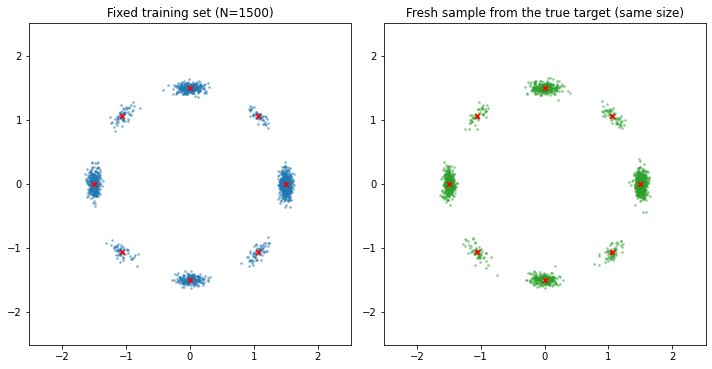

In [9]:
# ============================================================
# The fixed dataset + consistency check + a look at it.
# ============================================================
N = 1500
ring_data = sample_ring(N)                            # drawn ONCE

# Consistency check (guards against stale-kernel accidents: data vs plotted centers).
d_chk = torch.cdist(ring_data, means).min(dim=1).values.max().item()
print("max dist of training points to nearest mode center:", round(d_chk, 3),
      "(should be < ~0.6)")
assert d_chk < 0.8, "ring_data and means are out of sync -- restart kernel and Run All"

# The training set, side by side with a fresh sample of the same size:
# they should be visually indistinguishable (the dataset is representative).
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 5))
a1.scatter(ring_data[:, 0], ring_data[:, 1], s=3, alpha=0.4)
a1.set_title(f"Fixed training set (N={N})")
a2.scatter(*sample_ring(N).T, s=3, alpha=0.4, c="C2")
a2.set_title("Fresh sample from the true target (same size)")
for a in (a1, a2):
    a.scatter(means[:, 0], means[:, 1], c="red", s=25, marker="x")
    a.set_aspect("equal"); a.set_xlim(-lim, lim); a.set_ylim(-lim, lim)
plt.tight_layout(); plt.show()

In [10]:
# ============================================================
# Train the diffusion model on the fixed dataset (EMA kept for sampling).
# ============================================================
print("training diffusion on the fixed dataset...")
ema_net = train_diffusion(ring_data, n_steps=10000)

training diffusion on the fixed dataset...
  step     0 (  0.0s) loss 0.9960
  step  1000 (  3.5s) loss 0.2812
  step  2000 (  7.1s) loss 0.2024
  step  3000 ( 10.9s) loss 0.2325
  step  4000 ( 15.1s) loss 0.2167
  step  5000 ( 19.2s) loss 0.2236
  step  6000 ( 23.0s) loss 0.2195
  step  7000 ( 26.7s) loss 0.1671
  step  8000 ( 30.0s) loss 0.1949
  step  9000 ( 33.2s) loss 0.1994
  trained in 36.7s (sampling uses the EMA weights)


In [11]:
# ============================================================
# Sample all variants:
#   diffusion with Tweedie, diffusion without (to see the sharpness effect),
#   Langevin with the kernel (empirical) score of the same data.
# ============================================================
t0 = time.time()
diff_emp    = generate_samples(ema_net, 2000, t_min=0.02, tweedie=True)
diff_raw    = generate_samples(ema_net, 2000, t_min=1e-3, tweedie=False)   # old behaviour
lang_emp    = langevin_fn(lambda x: kde_score(x, ring_data, 0.05), 2000,
                          n_steps=2000, step=5e-4, init_std=1.5)
print(f"sampling done in {time.time()-t0:.1f}s")

sampling done in 33.0s


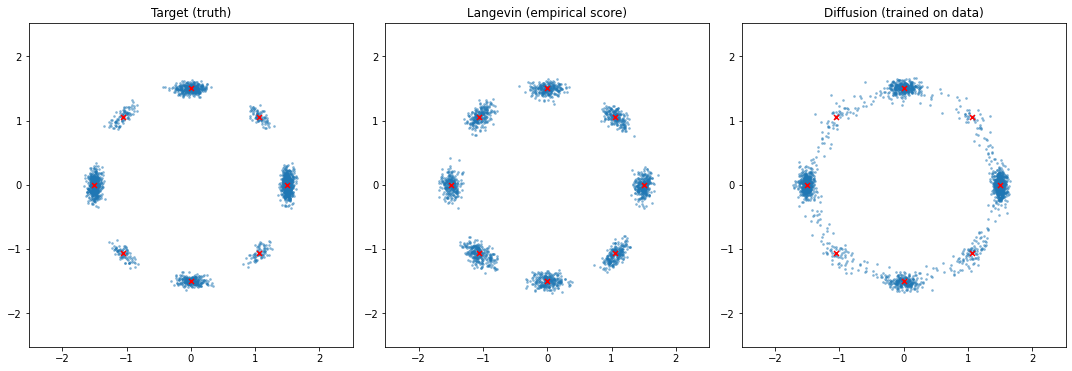

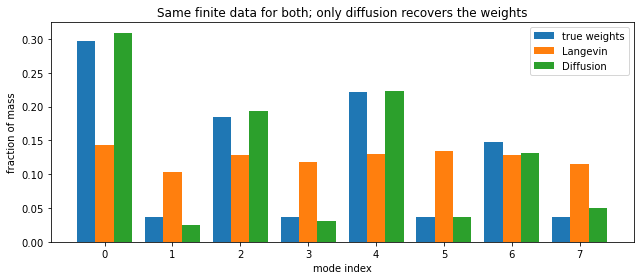

                metric        Langevin       Diffusion
------------------------------------------------------
      weight-TV (down)          0.3229          0.0343
      mean loglik (up)         -0.6883         -0.4336
          MMD^2 (down)          0.0029          0.0003
      sliced-W2 (down)          0.0706          0.0148


In [12]:
# ============================================================
# Three-column comparison + weights + metric table.
# ============================================================
truth = sample_ring(2000)
clouds = [("Target (truth)", truth),
          ("Langevin (empirical score)", lang_emp),
          ("Diffusion (trained on data)", diff_emp)]
plt.figure(figsize=(15, 5))
for i, (name, pts) in enumerate(clouds):
    plt.subplot(1, 3, i + 1)
    plt.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.4)
    plt.scatter(means[:, 0], means[:, 1], c="red", s=25, marker="x")
    plt.gca().set_aspect("equal"); plt.xlim(-lim, lim); plt.ylim(-lim, lim)
    plt.title(name)
plt.tight_layout(); plt.show()

idx = torch.arange(n_modes); w = 0.27
plt.figure(figsize=(9, 4))
plt.bar(idx - w, weights,                         width=w, label="true weights")
plt.bar(idx,     mode_fractions(lang_emp, means), width=w, label="Langevin")
plt.bar(idx + w, mode_fractions(diff_emp, means), width=w, label="Diffusion")
plt.xlabel("mode index"); plt.ylabel("fraction of mass")
plt.title("Same finite data for both; only diffusion recovers the weights")
plt.legend(); plt.tight_layout(); plt.show()

ref = sample_ring(2000)
def gmm_metrics(gen):
    return {"weight-TV (down)": weight_tv(gen, means, weights),
            "mean loglik (up)": mean_loglik(gen, weights, means, covs),
            "MMD^2 (down)":     rbf_mmd2(gen, ref),
            "sliced-W2 (down)": sliced_w2(gen, ref)}
print_table({"Langevin":  gmm_metrics(lang_emp),
             "Diffusion": gmm_metrics(diff_emp)})

### Evaluation sample sizes in Experiment 1

- The displayed target, Langevin and learned reverse-SDE clouds contain 2,000 points each.
- The MMD and sliced-Wasserstein reference is a separate 2,000-point population sample.
- The MMD bandwidth is fitted separately for each generated/reference pair.
- The sliced-Wasserstein function draws a fresh set of 128 directions for each method.
- Reported values are single Monte-Carlo realizations and have no standard error attached.


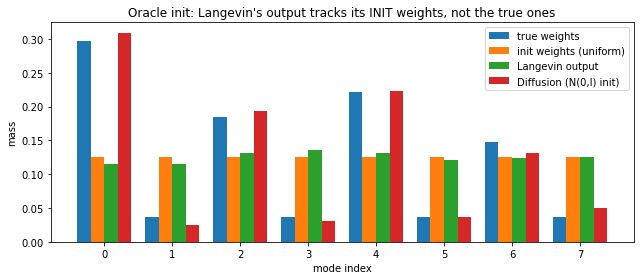

In [13]:
# ============================================================
# Ablation: oracle initialization ON the modes but with UNIFORM
# weights. Prediction: metastable Langevin freezes the per-basin
# mass, so the output weights stay ~uniform instead of the true ones.
# ============================================================
def init_on_modes_uniform(n):
    comp = torch.randint(0, n_modes, (n,))               # uniform mode choice
    a = angles[comp]
    ur = torch.stack([torch.cos(a),  torch.sin(a)], dim=1)
    ut = torch.stack([-torch.sin(a), torch.cos(a)], dim=1)
    return R * ur + (torch.randn(n, 1) * sigma_r) * ur + (torch.randn(n, 1) * sigma_t) * ut

x = init_on_modes_uniform(2000)
for _ in range(2000):
    x = x + 0.5 * 5e-4 * kde_score(x, ring_data, 0.05) \
          + math.sqrt(5e-4) * torch.randn_like(x)
lang_oracle = x

idx = torch.arange(n_modes); w = 0.2
plt.figure(figsize=(9, 4))
plt.bar(idx - 1.5*w, weights,                            width=w, label="true weights")
plt.bar(idx - 0.5*w, torch.full((n_modes,), 1/n_modes),  width=w, label="init weights (uniform)")
plt.bar(idx + 0.5*w, mode_fractions(lang_oracle, means), width=w, label="Langevin output")
plt.bar(idx + 1.5*w, mode_fractions(diff_emp, means),    width=w, label="Diffusion (N(0,I) init)")
plt.xlabel("mode index"); plt.ylabel("mass")
plt.title("Oracle init: Langevin's output tracks its INIT weights, not the true ones")
plt.legend(); plt.tight_layout(); plt.show()

### Uniform-mode initialization ablation

`init_on_modes_uniform` selects each of the eight centres with probability \(1/8\), then applies the
same radial/tangential Gaussian perturbations \((0.05,0.12)\) used by the population components.
The resulting 2,000 endpoints receive 2,000 KDE-score Langevin updates with
\(h=5\times10^{-4}\). This ablation changes only the implemented Langevin initialization relative
to `lang_emp`; it remains one finite-budget run.


### Terminal-time and Tweedie configuration

Two learned reverse-SDE configurations are retained:

| Name in code | Time interval | EM updates | Final Tweedie step |
|---|---:|---:|---:|
| `diff_emp` | \(1\to0.02\) | 1,999 | yes |
| `diff_raw` | \(1\to0.001\) | 1,999 | no |

The final plug-in map is

\[
\widehat X_0=
\frac{X_{t_*}+v_{t_*}s_\theta(X_{t_*},t_*)}{\mu_{t_*}}.
\]

With an exact marginal score it equals \(\mathbb E[X_0\mid X_{t_*}]\); with the learned score it
is the corresponding plug-in estimator. This archived comparison changes both the stopping time
and the presence of the final map, so its numerical difference is not an isolated causal estimate
of the Tweedie step alone.


In [14]:
# ============================================================
# Radial sharpness with vs without the Tweedie step + memorization probe.
# ============================================================
print(f"radial std   truth: {radial_std(truth):.4f}   (sigma_r = {sigma_r})")
print(f"radial std   diffusion WITHOUT Tweedie: {radial_std(diff_raw):.4f}")
print(f"radial std   diffusion WITH    Tweedie: {radial_std(diff_emp):.4f}")

baseline = nearest_data_dist(truth, ring_data)        # what a FRESH sample scores
print(f"\nnearest-data dist   truth baseline: {baseline:.4f}")
print(f"nearest-data dist   diffusion:      {nearest_data_dist(diff_emp, ring_data):.4f}"
      "   (~baseline = generalizes, ~0 = memorizes)")

radial std   truth: 0.0503   (sigma_r = 0.05)
radial std   diffusion WITHOUT Tweedie: 0.1063
radial std   diffusion WITH    Tweedie: 0.0666

nearest-data dist   truth baseline: 0.0088
nearest-data dist   diffusion:      0.0090   (~baseline = generalizes, ~0 = memorizes)


### Score diagnostics — learned, empirical and population scores

For the fixed dataset \(\mathcal D=\{x^{(1)},\ldots,x^{(N)}\}\), the noised empirical law is

\[
\widehat p_t(x)=\frac1N\sum_{i=1}^N
\mathcal N(x;\mu_tx^{(i)},v_tI_2).
\]

Its exact score is

\[
s_{\mathrm{emp},t}(x)
=\frac{\sum_i\omega_i(x,t)\mu_tx^{(i)}-x}{v_t},
\qquad
\omega_i(x,t)\propto
\exp\!\left[-\frac{\|x-\mu_tx^{(i)}\|^2}{2v_t}\right].
\]

Because the population target is a GMM, its noised marginal is also explicit:

\[
p_t(x)=\sum_k w_k\,
\mathcal N\!\left(x;\mu_tm_k,\mu_t^2\Sigma_k+v_tI_2\right).
\]

At every reported time \(t\in\{0.02,0.05,0.10,0.30,0.60\}\), 4,000 points are sampled from
the noised empirical law by drawing training observations with replacement and applying the VP
transition kernel. For two vector fields \(a,b\), the printed relative statistic is

\[
E(a,b)=
\frac{M^{-1}\sum_{i=1}^M\|a(X_i)-b(X_i)\|_2}
     {M^{-1}\sum_{i=1}^M\|b(X_i)\|_2}.
\]

It is a ratio of mean Euclidean norms, not a root-mean-square error and not the mean of pointwise
relative errors. The identity

\[
s_\theta-s_{\mathrm{true}}
=(s_\theta-s_{\mathrm{emp}})+(s_{\mathrm{emp}}-s_{\mathrm{true}})
\]

motivates the three columns, but the norms themselves do not add linearly.

The spatial diagnostic at \(t=0.1\) uses a \(24\times24\) grid on
\([-2.52,2.52]^2\). The quiver panels normalize each nonzero score vector and therefore display
direction only. The heatmap displays the absolute Euclidean error
\(\|s_\theta-s_{\mathrm{true}}\|_2\). Its printed density-weighted relative statistic uses discrete
grid weights \(w_j\propto p_t(x_j)\):

\[
\frac{\sum_jw_j\|s_\theta(x_j,t)-s_{\mathrm{true}}(x_j,t)\|_2}
     {\sum_jw_j\|s_{\mathrm{true}}(x_j,t)\|_2}.
\]


In [15]:
# ============================================================
# Three-way relative errors on noised data points (where the loss lives).
# ============================================================
print(f"{'t':>6} {'|net-emp|/|emp|':>17} {'|net-true|/|true|':>19} {'|emp-true|/|true|':>19}")
for t_eval in [0.02, 0.05, 0.1, 0.3, 0.6]:
    ib = (0.1 + 0.5 * (20 - 0.1) * t_eval) * t_eval
    mu_t, var_t = math.exp(-0.5 * ib), 1 - math.exp(-ib)
    x0 = ring_data[torch.randint(0, N, (4000,))]
    xt = mu_t * x0 + math.sqrt(var_t) * torch.randn_like(x0)
    _, s_true = gmm_log_prob_and_score(xt, weights, mu_t * means,
                                       (mu_t ** 2) * covs + var_t * torch.eye(2))
    s_emp = empirical_score_t(xt, ring_data, t_eval)
    with torch.no_grad():
        s_net = ema_net(xt, torch.full((xt.shape[0], 1), float(t_eval)))
    rel = lambda a, b: ((a - b).norm(dim=1).mean() / b.norm(dim=1).mean()).item()
    print(f"{t_eval:>6.2f} {rel(s_net, s_emp):>17.3f} {rel(s_net, s_true):>19.3f} "
          f"{rel(s_emp, s_true):>19.3f}")

     t   |net-emp|/|emp|   |net-true|/|true|   |emp-true|/|true|
  0.02             0.415               0.400               0.100
  0.05             0.137               0.133               0.043
  0.10             0.062               0.066               0.035
  0.30             0.027               0.039               0.027
  0.60             0.013               0.014               0.004


density-weighted relative error: 0.0673


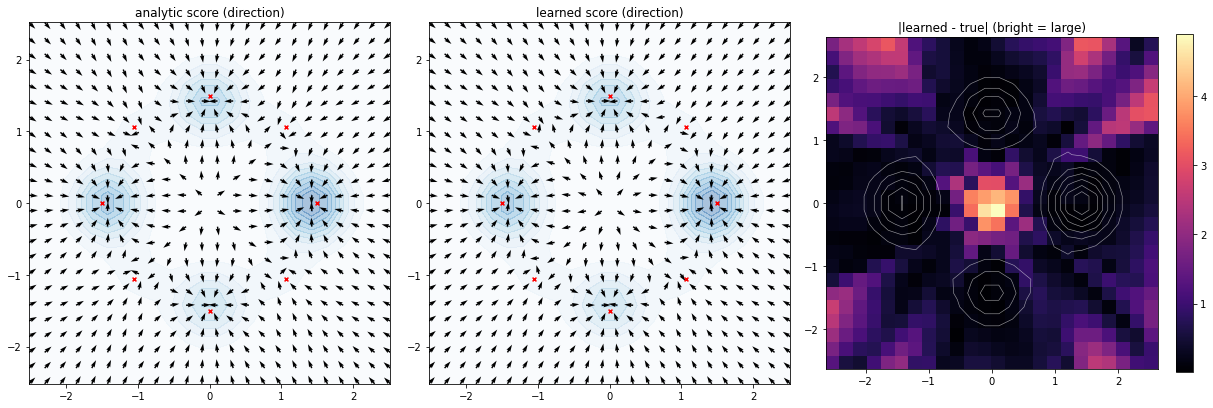

In [16]:
# ============================================================
# Direction fields + error map at t = 0.1 (density-weighted view).
# ============================================================
t_eval = 0.1
ib = (0.1 + 0.5 * (20 - 0.1) * t_eval) * t_eval
mu_t, var_t = math.exp(-0.5 * ib), 1 - math.exp(-ib)
means_t = mu_t * means
covs_t = (mu_t ** 2) * covs + var_t * torch.eye(2)

g = torch.linspace(-lim, lim, 24)
grid = torch.stack([g.repeat(24), g.repeat_interleave(24)], dim=1)
lp, s_true = gmm_log_prob_and_score(grid, weights, means_t, covs_t)
with torch.no_grad():
    s_net = ema_net(grid, torch.full((grid.shape[0], 1), float(t_eval)))

err = (s_net - s_true).norm(dim=1)
w_dens = torch.softmax(lp, dim=0)
print("density-weighted relative error:",
      round(((w_dens * err).sum() / (w_dens * s_true.norm(dim=1)).sum()).item(), 4))

dens2 = torch.exp(lp).reshape(24, 24).numpy()
unit = lambda s: (s / s.norm(dim=1, keepdim=True).clamp_min(1e-8)).numpy()
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, u, name in [(a1, unit(s_true), "analytic score (direction)"),
                    (a2, unit(s_net),  "learned score (direction)")]:
    ax.contourf(g.numpy(), g.numpy(), dens2, levels=12, cmap="Blues", alpha=0.35)
    ax.quiver(grid[:, 0], grid[:, 1], u[:, 0], u[:, 1],
              angles="xy", scale_units="xy", scale=8, width=0.004)
    ax.scatter(means[:, 0], means[:, 1], c="red", s=15, marker="x")
    ax.set_aspect("equal"); ax.set_title(name)
pcm = a3.pcolormesh(g.numpy(), g.numpy(), err.reshape(24, 24).numpy(),
                    cmap="magma", shading="auto")
a3.contour(g.numpy(), g.numpy(), dens2, levels=6, colors="white", alpha=0.6, linewidths=0.6)
a3.set_aspect("equal"); a3.set_title("|learned - true| (bright = large)")
fig.colorbar(pcm, ax=a3, fraction=0.046)
plt.tight_layout(); plt.show()

In [17]:
# Where does the excess spread enter?
t_min = 0.02
x_tmin = generate_samples(ema_net, 2000, t_min=t_min, tweedie=False)  # marginal at t_min
ib = (0.1 + 0.5 * (20 - 0.1) * t_min) * t_min
mu_t, var_t = math.exp(-0.5 * ib), 1 - math.exp(-ib)
theor = math.sqrt((mu_t * sigma_r) ** 2 + var_t)          # radial std p_{t_min} should have
print(f"radial std at t_min: {radial_std(x_tmin):.4f}  vs theoretical {theor:.4f}")
print(f"radial std after Tweedie: {radial_std(diff_emp):.4f}  vs target {sigma_r}")

radial std at t_min: 0.1027  vs theoretical 0.0919
radial std after Tweedie: 0.0666  vs target 0.05


### Radial diagnostic at \(t_{\min}\)

The printed comparison uses

\[
\sqrt{\mu_{t_{\min}}^2\sigma_r^2+v_{t_{\min}}}
\]

as a local radial standard-deviation benchmark for the noised mixture. This expression propagates
the radial Gaussian variance and adds isotropic VP noise; it is a diagnostic approximation rather
than an exact formula for the standard deviation of \(\|X_{t_{\min}}\|_2\), which also depends on
curvature and tangential perturbations.


## Experiment 2 — Gaussian-KDE scores on a modulated thin annulus

### Reference-data generator

The function `sample_annulus` draws independently

\[
\Theta\sim q_a,\qquad
q_a(\theta)=\frac{1+a\cos\theta}{2\pi},\qquad
\rho=R+sZ,\quad Z\sim\mathcal N(0,1),
\]

and returns \(X=\rho(\cos\Theta,\sin\Theta)\), with

\[
R=1.5,\qquad s=0.07,\qquad a=0.6.
\]

Angles are obtained by rejection sampling from the uniform law on \([0,2\pi)\) with acceptance
probability \((1+a\cos\theta)/(1+a)\). The Gaussian radius is not truncated; negative radii are
possible but have negligible probability for the parameters used.

### Analytic vector field actually used

For \(x\ne0\), the code supplies Langevin with

\[
s_{\mathrm{ann}}(x)
=-\frac{r-R}{s^2}e_r
-\frac{a\sin\theta}{r(1+a\cos\theta)}e_\theta,
\qquad r=\|x\|,
\]

where \(e_r=(\cos\theta,\sin\theta)^\top\) and
\(e_\theta=(-\sin\theta,\cos\theta)^\top\). Numerically, \(r\) is clipped below at \(10^{-6}\).
This is the Lebesgue score of

\[
\widetilde p_{\mathrm{ann}}(x)
\propto
\exp\!\left[-\frac{(\|x\|-R)^2}{2s^2}\right](1+a\cos\theta).
\]

### Measure convention retained by the archive

The reference-data generator and this analytic vector field are close for the thin annuli used,
but they are **not exactly the same probability measure**. Ignoring the negligible negative-radius
term, transforming the sampled \((\rho,\Theta)\) law to Cartesian coordinates introduces a
Jacobian factor \(1/r\):

If \(\phi_s(z)=(2\pi s^2)^{-1/2}\exp[-z^2/(2s^2)]\), the exact Cartesian density generated by
the signed radius is, for \(x=r(\cos\theta,\sin\theta)\) and \(r>0\),

\[
p_{\mathrm{sample}}(x)=\frac{1}{2\pi r}\left[
\phi_s(r-R)(1+a\cos\theta)+
\phi_s(-r-R)(1-a\cos\theta)
\right].
\]

Here \(\Pr(\rho<0)=\Phi(-R/s)<10^{-100}\), so the second term is numerically negligible and

\[
p_{\mathrm{sample}}(x)
\propto
\frac1r\exp\!\left[-\frac{(r-R)^2}{2s^2}\right](1+a\cos\theta),
\]

whose radial score contains an additional \(-1/r\) term. The archive deliberately preserves both
original functions and records them as two separately defined implemented objects; it does not
claim that `annulus_score` is the exact score of `sample_annulus`.

### Main protocol

| Item | Implemented configuration |
|---|---|
| Fixed small dataset | 40 reference-generator observations |
| Additional dataset | 400 independently generated observations |
| KDE | Isotropic Gaussian, bandwidth \(b=0.07\) |
| Output per Langevin run | 2,000 independent chain endpoints |
| Initialization | \(\mathcal N(0,1.5^2I_2)\) |
| Updates | 3,000, with \(h=2\times10^{-3}\), total time \(Kh=6\) |
| Angular histogram | 60 bins on \([-\pi,\pi]\), normalized as a density |
| Population/reference samples | 2,000 |
| Repetitions | One run |

Here “empirical score” means the exact score of the Gaussian-smoothed empirical distribution

\[
\widehat p_b(x)=\frac1N\sum_{i=1}^N\mathcal N(x;x^{(i)},b^2I_2),
\]

not a score of the discrete empirical measure itself.


In [18]:
# ============================================================
# Connected modulated annulus: analytic score + exact sampler + 40-point set.
# ============================================================
R_a, s_ann, a_mod = 1.5, 0.07, 0.6

def annulus_score(x):
    r = x.norm(dim=1, keepdim=True).clamp_min(1e-6)
    xhat = x / r
    that = torch.stack([-x[:, 1], x[:, 0]], dim=1) / r
    cos, sin = x[:, :1] / r, x[:, 1:] / r
    radial = -(r - R_a) / s_ann ** 2
    tang = -a_mod * sin / ((1 + a_mod * cos) * r)
    return radial * xhat + tang * that

def sample_annulus(n):
    th = torch.empty(0)
    while th.numel() < n:
        p = 2 * math.pi * torch.rand(4 * n)
        keep = torch.rand(4 * n) < (1 + a_mod * torch.cos(p)) / (1 + a_mod)
        th = torch.cat([th, p[keep]])
    th = th[:n]; r = R_a + s_ann * torch.randn(n)
    return torch.stack([r * torch.cos(th), r * torch.sin(th)], dim=1)

annulus_data = sample_annulus(40)                      # the small fixed dataset

t0 = time.time()
lang_ana  = langevin_fn(annulus_score, 2000, n_steps=3000, step=2e-3, init_std=1.5)
lang_kde40 = langevin_fn(lambda x: kde_score(x, annulus_data, 0.07), 2000,
                         n_steps=3000, step=2e-3, init_std=1.5)
print(f"annulus Langevin runs done in {time.time()-t0:.1f}s")

annulus Langevin runs done in 3.2s


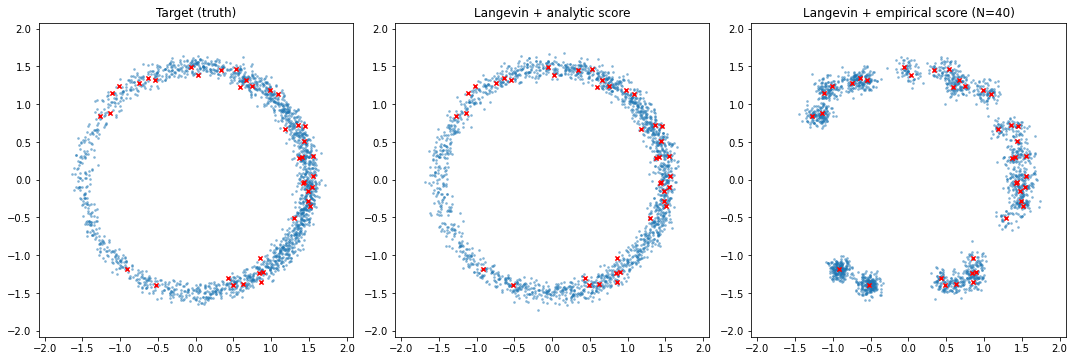

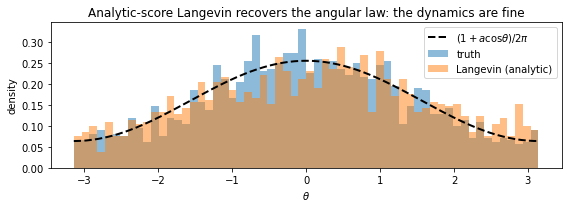

In [19]:
# ============================================================
# Scatter comparison + angular-density check for the analytic run.
# ============================================================
truth_a = sample_annulus(2000)
lim_a = R_a + 4 * s_ann + 0.3
clouds_a = [("Target (truth)", truth_a),
            ("Langevin + analytic score", lang_ana),
            ("Langevin + empirical score (N=40)", lang_kde40)]
plt.figure(figsize=(15, 5))
for i, (name, pts) in enumerate(clouds_a):
    plt.subplot(1, 3, i + 1)
    plt.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.4)
    plt.scatter(annulus_data[:, 0], annulus_data[:, 1], c="red", s=18, marker="x")
    plt.gca().set_aspect("equal"); plt.xlim(-lim_a, lim_a); plt.ylim(-lim_a, lim_a)
    plt.title(name)
plt.tight_layout(); plt.show()

# Angular histogram: analytic-score Langevin vs truth vs the analytic curve.
grid_th = np.linspace(-np.pi, np.pi, 300)
ref_curve = (1 + a_mod * np.cos(grid_th)) / (2 * np.pi)
plt.figure(figsize=(8, 3))
plt.hist(torch.atan2(truth_a[:, 1], truth_a[:, 0]).numpy(), bins=60,
         range=(-np.pi, np.pi), density=True, alpha=0.5, label="truth")
plt.hist(torch.atan2(lang_ana[:, 1], lang_ana[:, 0]).numpy(), bins=60,
         range=(-np.pi, np.pi), density=True, alpha=0.5, label="Langevin (analytic)")
plt.plot(grid_th, ref_curve, "k--", lw=2, label=r"$(1+a\cos\theta)/2\pi$")
plt.xlabel(r"$\theta$"); plt.ylabel("density"); plt.legend()
plt.title("Analytic-score Langevin recovers the angular law: the dynamics are fine")
plt.tight_layout(); plt.show()





### Effect of dataset size at fixed KDE bandwidth

The notebook repeats the KDE-score Langevin calculation with independently generated datasets of
sizes \(N=40\) and \(N=400\), while keeping bandwidth \(b=0.07\), initialization, chain count,
step size and iteration count fixed.

At fixed positive bandwidth, increasing \(N\) reduces the finite-sample variability of the KDE and
its score; the limiting target remains the bandwidth-smoothed population distribution rather than
the unsmoothed population law. The displayed comparison records this fixed-bandwidth finite-sample
effect. The nearest-training-point statistic is computed against 40 and 400 points respectively,
so its raw values across the two columns have different nearest-neighbour baselines.


N=400 run done in 8.2s


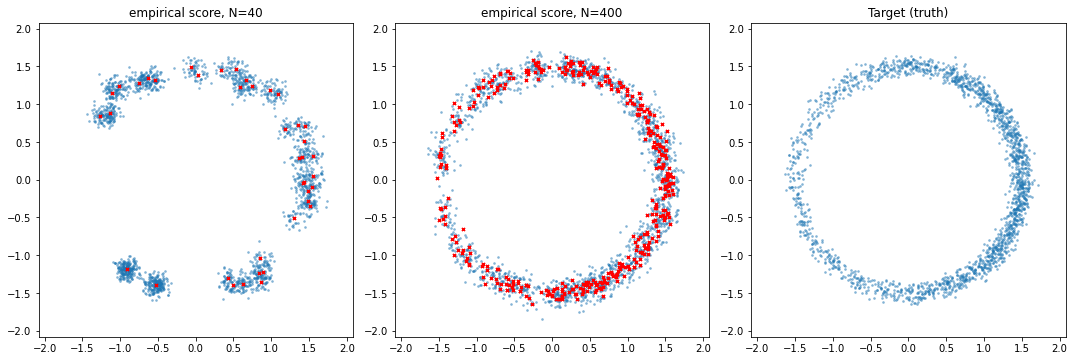

                metric        analytic        KDE N=40       KDE N=400
----------------------------------------------------------------------
          MMD^2 (down)          0.0017          0.0127          0.0033
      sliced-W2 (down)          0.0118          0.0824          0.0190
  nearest-data (probe)          0.1200          0.0724          0.0374

(truth baseline vs the 40 pts: 0.117 -- KDE N=40 far below it = memorization.)


In [20]:
# ============================================================
# Same kernel-score Langevin with N = 40 vs N = 400.
# ============================================================
annulus_data400 = sample_annulus(400)
t0 = time.time()
lang_kde400 = langevin_fn(lambda x: kde_score(x, annulus_data400, 0.07), 2000,
                          n_steps=3000, step=2e-3, init_std=1.5)
print(f"N=400 run done in {time.time()-t0:.1f}s")

plt.figure(figsize=(15, 5))
for i, (name, pts, marks) in enumerate([
        ("empirical score, N=40",  lang_kde40,  annulus_data),
        ("empirical score, N=400", lang_kde400, annulus_data400),
        ("Target (truth)",         truth_a,     None)]):
    plt.subplot(1, 3, i + 1)
    plt.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.4)
    if marks is not None:
        plt.scatter(marks[:, 0], marks[:, 1], c="red", s=10, marker="x")
    plt.gca().set_aspect("equal"); plt.xlim(-lim_a, lim_a); plt.ylim(-lim_a, lim_a)
    plt.title(name)
plt.tight_layout(); plt.show()

ref_a = sample_annulus(2000)
def annulus_metrics(gen, data):
    return {"MMD^2 (down)":         rbf_mmd2(gen, ref_a),
            "sliced-W2 (down)":     sliced_w2(gen, ref_a),
            "nearest-data (probe)": nearest_data_dist(gen, data)}
print_table({"analytic":  annulus_metrics(lang_ana, annulus_data),
             "KDE N=40":  annulus_metrics(lang_kde40, annulus_data),
             "KDE N=400": annulus_metrics(lang_kde400, annulus_data400)})
print("\n(truth baseline vs the 40 pts:",
      round(nearest_data_dist(truth_a, annulus_data), 3),
      "-- KDE N=40 far below it = memorization.)")

### Thinness study protocol

The next cell uses \(R=1.5\), \(a=0.6\) and
\(s\in\{0.30,0.15,0.07\}\). For each value, 2,000 chains start at angle zero with
\(r\sim\mathcal N(R,s^2)\), and 4,000 updates use \(h=0.02s^2\).

| \(s\) | \(h=0.02s^2\) | Updates | Total discretized time \(Kh\) |
|---:|---:|---:|---:|
| 0.30 | 0.0018 | 4,000 | 7.2 |
| 0.15 | 0.00045 | 4,000 | 1.8 |
| 0.07 | 0.000098 | 4,000 | 0.392 |

Thus the number of updates is fixed, but the total discretized time is not. The reported left-half
mass is \(M^{-1}\sum_i\mathbf 1_{\{X_{i,1}<0\}}\). The angular reference value is

\[
\Pr(\cos\Theta<0)=\frac12-\frac a\pi\simeq0.3090.
\]


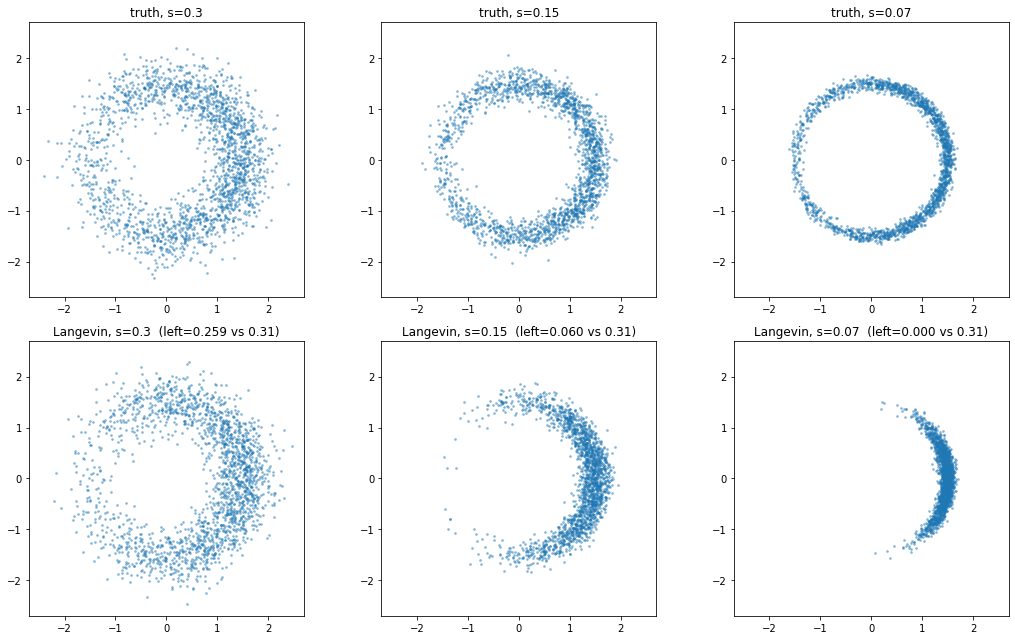

s =  0.30   left-half mass = 0.259   (target 0.309)
s =  0.15   left-half mass = 0.060   (target 0.309)
s =  0.07   left-half mass = 0.000   (target 0.309)


In [21]:
# ============================================================
# Manifold-thinness effect on Langevin, ISOLATED: exact analytic
# score everywhere; only the manifold thickness s varies.
# Same step budget for all; step size at stability limit ~ s^2.
# All chains start at theta=0; success = recovering left mass ~0.31.
# ============================================================
R_a, a_mod = 1.5, 0.6
target_left = 0.5 - a_mod / math.pi

def make_score(s):
    def score(x):
        r = x.norm(dim=1, keepdim=True).clamp_min(1e-6)
        xhat = x / r
        that = torch.stack([-x[:, 1], x[:, 0]], dim=1) / r
        cos, sin = x[:, :1] / r, x[:, 1:] / r
        return (-(r - R_a) / s**2) * xhat + (-a_mod * sin / ((1 + a_mod * cos) * r)) * that
    return score

def sample_annulus_s(n, s):
    th = torch.empty(0)
    while th.numel() < n:
        p = 2 * math.pi * torch.rand(4 * n)
        keep = torch.rand(4 * n) < (1 + a_mod * torch.cos(p)) / (1 + a_mod)
        th = torch.cat([th, p[keep]])
    th = th[:n]; r = R_a + s * torch.randn(n)
    return torch.stack([r * torch.cos(th), r * torch.sin(th)], dim=1)

s_values = [0.30, 0.15, 0.07]
n_steps, n_pts = 4000, 2000
results = []
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for j, s in enumerate(s_values):
    step = 0.02 * s**2                                   # stability-limited step
    r0 = R_a + s * torch.randn(n_pts)
    x = torch.stack([r0, torch.zeros(n_pts)], dim=1)     # adversarial init: all at theta=0
    sc = make_score(s)
    for _ in range(n_steps):
        x = x + 0.5 * step * sc(x) + math.sqrt(step) * torch.randn_like(x)
    left = (x[:, 0] < 0).float().mean().item()
    results.append(left)
    truth_s = sample_annulus_s(n_pts, s)
    for ax, pts, tag in [(axes[0, j], truth_s, "truth"), (axes[1, j], x, "Langevin")]:
        ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.4)
        ax.set_aspect("equal"); ax.set_xlim(-2.7, 2.7); ax.set_ylim(-2.7, 2.7)
        ax.set_title(f"{tag}, s={s}" + (f"  (left={left:.3f} vs {target_left:.2f})"
                                        if tag == "Langevin" else ""))
plt.tight_layout(); plt.show()

for s, l in zip(s_values, results):
    print(f"s = {s:>5.2f}   left-half mass = {l:.3f}   (target {target_left:.3f})")

### Learned diffusion on the same 40 observations

The network uses exactly the 40 observations already stored in `annulus_data`. It receives 3,000
Adam updates with requested batch size 64; because `train_diffusion` uses
`min(batch, N)`, the effective batch contains 40 indices sampled with replacement at every update.
The learning rate is \(10^{-3}\), EMA decay is 0.999, and 2,000 samples are generated with 1,999
Euler–Maruyama updates from \(t=1\) to \(t=0.02\), followed by the Tweedie plug-in step.

The KDE score is the unrestricted population minimizer of the corresponding Gaussian-denoising
objective for the empirical distribution. The finite neural network, finite optimization run and
EMA need not realize that minimizer. The median nearest-training-point statistic is used only as an
operational comparison with an independent-reference baseline; it does not by itself establish a
formal generalization or memorization theorem.


training diffusion on the 40 annulus points...
  step     0 (  0.0s) loss 0.7099
  step  1000 (  2.6s) loss 0.1075
  step  2000 (  5.3s) loss 0.1559
  trained in 8.1s (sampling uses the EMA weights)


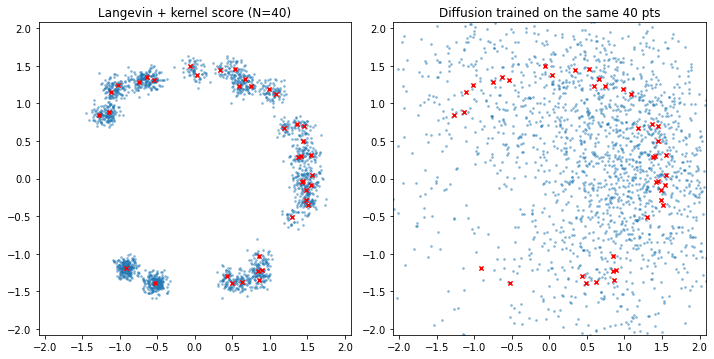

nearest-data dist   truth baseline:      0.1174
nearest-data dist   Langevin+kernel:     0.0724   (memorization limit)
nearest-data dist   diffusion (network): 0.4044   (between the two = smoothing)


In [22]:
# ============================================================
# Diffusion trained on the SAME 40 points.
# ============================================================
print("training diffusion on the 40 annulus points...")
net40 = train_diffusion(annulus_data, n_steps=3000, batch=64, log_every=1000)
diff40 = generate_samples(net40, 2000, t_min=0.02)

plt.figure(figsize=(10, 5))
for i, (name, pts) in enumerate([("Langevin + kernel score (N=40)", lang_kde40),
                                  ("Diffusion trained on the same 40 pts", diff40)]):
    plt.subplot(1, 2, i + 1)
    plt.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.4)
    plt.scatter(annulus_data[:, 0], annulus_data[:, 1], c="red", s=18, marker="x")
    plt.gca().set_aspect("equal"); plt.xlim(-lim_a, lim_a); plt.ylim(-lim_a, lim_a)
    plt.title(name)
plt.tight_layout(); plt.show()

print(f"nearest-data dist   truth baseline:      "
      f"{nearest_data_dist(truth_a, annulus_data):.4f}")
print(f"nearest-data dist   Langevin+kernel:     "
      f"{nearest_data_dist(lang_kde40, annulus_data):.4f}   (memorization limit)")
print(f"nearest-data dist   diffusion (network): "
      f"{nearest_data_dist(diff40, annulus_data):.4f}   (between the two = smoothing)")

### Stateful checkpoint trajectory

The following cell creates a **new** network and trains it continuously to cumulative checkpoints

\[
250,500,1000,2000,4000,8000,16000,32000.
\]

At each checkpoint, the current EMA network generates 1,000 samples with the default learned
reverse-SDE configuration (1,999 updates from 1 to 0.02 and a Tweedie step). These are not eight
independent training runs. Sampling consumes the same global PyTorch random stream used by later
mini-batch and forward-noise draws, so removing or reordering a checkpoint changes the continuation
of training. The curve is an archived stateful trajectory, not a repeated-run learning curve.


steps    250   nearest-data dist = 146.8969
steps    500   nearest-data dist = 57.0982
steps   1000   nearest-data dist = 7.2752
steps   2000   nearest-data dist = 0.5744
steps   4000   nearest-data dist = 0.2890
steps   8000   nearest-data dist = 0.1545
steps  16000   nearest-data dist = 0.1029
steps  32000   nearest-data dist = 0.0886


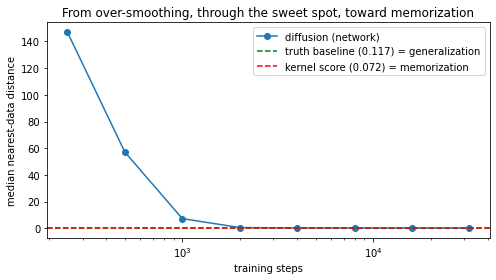

In [23]:
# ============================================================
# Training-time trajectory: over-smoothing -> sweet spot -> memorization.
# ============================================================
checkpoints = [250, 500, 1000, 2000, 4000, 8000, 16000, 32000]
net = ScoreMLP().to(device)
opt = torch.optim.Adam(net.parameters(), lr=1e-3)
ema = {k: v.clone() for k, v in net.state_dict().items()}

dists, step = [], 0
for target in checkpoints:
    while step < target:
        x = annulus_data[torch.randint(0, 40, (40,))]
        opt.zero_grad(); loss = calc_loss(net, x); loss.backward(); opt.step()
        with torch.no_grad():
            for k, v in net.state_dict().items():
                ema[k].mul_(0.999).add_(v, alpha=0.001)
        step += 1
    ema_net_ck = ScoreMLP().to(device); ema_net_ck.load_state_dict(ema)
    s = generate_samples(ema_net_ck, 1000, t_min=0.02)
    dists.append(nearest_data_dist(s, annulus_data))
    print(f"steps {target:>6d}   nearest-data dist = {dists[-1]:.4f}")

baseline = nearest_data_dist(truth_a, annulus_data)
kde_level = nearest_data_dist(lang_kde40, annulus_data)
plt.figure(figsize=(7, 4))
plt.plot(checkpoints, dists, "o-", label="diffusion (network)")
plt.axhline(baseline, ls="--", c="g", label=f"truth baseline ({baseline:.3f}) = generalization")
plt.axhline(kde_level, ls="--", c="r", label=f"kernel score ({kde_level:.3f}) = memorization")
plt.xscale("log"); plt.xlabel("training steps"); plt.ylabel("median nearest-data distance")
plt.title("From over-smoothing, through the sweet spot, toward memorization")
plt.legend(); plt.tight_layout(); plt.show()

## Experiment 3 — analytic scores for a concentric-ring GMM

The target is a normalized 14-component GMM.

- **Inner ring:** 8 equally spaced means at radius 1.5, radial standard deviation 0.05,
  tangential standard deviation 0.12 and raw component weight 3.
- **Outer ring:** 6 equally spaced means at radius 5, radial standard deviation 0.05,
  tangential standard deviation 0.30 and raw component weight 1.5.

After normalization, every inner component has weight \(1/11\), every outer component has weight
\(1/22\), and the total inner/outer masses are \(8/11\) and \(3/11\).

| Sampler | Implemented configuration |
|---|---|
| Plain Langevin | 3,000 chains; exact \(\nabla\log p_0\); \(X_0\sim\mathcal N(0,I_2)\); 2,000 updates; \(h=5\times10^{-4}\); total time 1 |
| Analytic reverse VP-SDE | 3,000 trajectories; exact family \((\nabla\log p_t)_{0\le t\le1}\); \(X_1\sim\mathcal N(0,I_2)\); 1,000 grid points and 999 Euler–Maruyama updates from 1 to 0; no Tweedie step |
| Truth/reference | Two independent samples of size 3,000 |

The exact VP marginal is

\[
p_t(x)=\sum_k w_k\,
\mathcal N\!\left(x;\mu_tm_k,\mu_t^2\Sigma_k+v_tI_2\right).
\]

At \(t=1\), the implemented \(\mathcal N(0,I_2)\) initialization is an extremely close but not
identical approximation to \(p_1\): the noised component-mean radii are approximately 0.00986 and
0.03286, and the centered mixture has global covariance approximately \(1.00014I_2\). The
comparison removes neural-score estimation error, while
retaining different score information and numerical budgets: Langevin queries \(\nabla\log p_0\)
2,000 times, whereas the reverse-SDE queries the family \(\nabla\log p_t\) 999 times along its
annealing path.


In [24]:
# ============================================================
# Concentric rings + exact-score samplers on both sides.
# ============================================================
def make_ring_gmm(n_modes, R0, sr, st, wscale):
    ang = torch.linspace(0, 2 * math.pi, n_modes + 1)[:-1]
    ur = torch.stack([torch.cos(ang),  torch.sin(ang)], dim=1)
    ut = torch.stack([-torch.sin(ang), torch.cos(ang)], dim=1)
    cov = sr ** 2 * (ur[:, :, None] * ur[:, None, :]) + st ** 2 * (ut[:, :, None] * ut[:, None, :])
    return R0 * ur, cov, torch.full((n_modes,), float(wscale))

def sample_gmm(n, weights, means, covs):
    L = torch.linalg.cholesky(covs)
    comp = torch.multinomial(weights, n, replacement=True)
    return means[comp] + (L[comp] @ torch.randn(n, 2, 1)).squeeze(-1)

mu1, cov1, w1 = make_ring_gmm(8, 1.5, 0.05, 0.12, 3.0)
mu2, cov2, w2 = make_ring_gmm(6, 5.0, 0.05, 0.30, 1.5)
means2 = torch.cat([mu1, mu2]); covs2 = torch.cat([cov1, cov2])
weights2 = torch.cat([w1, w2]); weights2 /= weights2.sum()

@torch.no_grad()
def reverse_sde_analytic(nsamples, weights, means, covs, n_steps=1000):
    x = torch.randn(nsamples, 2)
    ts = torch.linspace(1, 0, n_steps); I = torch.eye(2)
    beta = lambda t: 0.1 + (20 - 0.1) * t
    for i in range(len(ts) - 1):
        t = float(ts[i]); dt = ts[i + 1] - ts[i]
        ib = (0.1 + 0.5 * (20 - 0.1) * t) * t
        mu_t, var_t = math.exp(-0.5 * ib), 1 - math.exp(-ib)
        _, sc = gmm_log_prob_and_score(x, weights, mu_t * means, (mu_t ** 2) * covs + var_t * I)
        g = beta(t) ** 0.5
        x = x + (-0.5 * beta(t) * x - g * g * sc) * dt + g * torch.randn_like(x) * abs(dt) ** 0.5
    return x

t0 = time.time()
lang2 = langevin_fn(lambda x: gmm_log_prob_and_score(x, weights2, means2, covs2)[1],
                    3000, n_steps=2000, step=5e-4, init_std=1.0)
rev2 = reverse_sde_analytic(3000, weights2, means2, covs2)
print(f"concentric runs done in {time.time()-t0:.1f}s")

concentric runs done in 7.4s


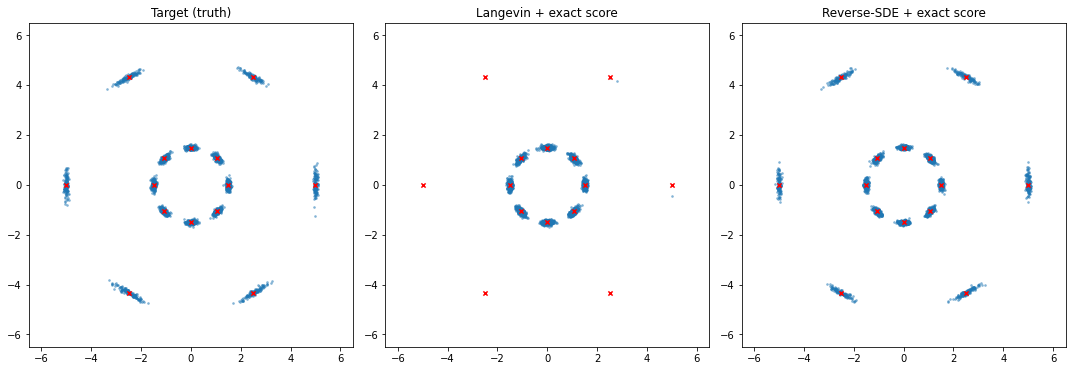

                metric        Langevin     Reverse-SDE
------------------------------------------------------
      weight-TV (down)          0.2717          0.0196
          MMD^2 (down)          0.0395         -0.0002
      sliced-W2 (down)          1.3583          0.0271


In [25]:
# ============================================================
# Scatter + metrics (Experiment 3).
# ============================================================
truth2 = sample_gmm(3000, weights2, means2, covs2)
clouds2 = [("Target (truth)", truth2),
           ("Langevin + exact score", lang2),
           ("Reverse-SDE + exact score", rev2)]
lim2 = 6.5
plt.figure(figsize=(15, 5))
for i, (name, pts) in enumerate(clouds2):
    plt.subplot(1, 3, i + 1)
    plt.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.4)
    plt.scatter(means2[:, 0], means2[:, 1], c="red", s=18, marker="x")
    plt.gca().set_aspect("equal"); plt.xlim(-lim2, lim2); plt.ylim(-lim2, lim2)
    plt.title(name)
plt.tight_layout(); plt.show()

ref2 = sample_gmm(3000, weights2, means2, covs2)
def conc_metrics(gen):
    return {"weight-TV (down)": weight_tv(gen, means2, weights2),
            "MMD^2 (down)":     rbf_mmd2(gen, ref2),
            "sliced-W2 (down)": sliced_w2(gen, ref2)}
print_table({"Langevin":    conc_metrics(lang2),
             "Reverse-SDE": conc_metrics(rev2)})

### Experiment 3 metric protocol

The displayed target and both sampler outputs contain 3,000 points. A separate 3,000-point
population sample is generated for MMD and sliced Wasserstein. `weight-TV` again refers to hard
nearest-centre categorical frequencies. The RBF MMD statistic is the unbiased estimator and may be
slightly negative; the statistic labelled `sliced-W2` is the squared sliced statistic defined above.
No method repetition or confidence interval is computed.


## Archived observations and scope

The single seeded execution records the following qualitative observations for the implemented
configurations:

- In Experiment 1, the learned reverse-SDE gives mode frequencies closer to the prescribed GMM
  weights than KDE-score Langevin under the recorded initializations and finite budgets. The score
  diagnostic separately records learned-to-empirical and empirical-to-population discrepancies.
- In Experiment 2, the 40-point KDE-score run is much more concentrated around its finite training
  set than the independently generated reference sample; increasing the dataset to 400 points at
  fixed bandwidth reduces the displayed sample discrepancies. The learned 40-point model and the
  training-duration trajectory retain their original outcomes.
- In Experiment 3, with analytic scores, the reverse VP-SDE recovers the prescribed inner/outer
  masses more closely than plain Langevin for the particular initializations and numerical budgets
  used.

These observations do not constitute repeated-run performance estimates. The archive intentionally
does not add error bars, hyperparameter sweeps, matched-cost baselines, Metropolis correction,
adaptive solvers or alternative metrics, because doing so would change the experimental content.

## Reproducibility limitations retained rather than changed

1. Seeds are set only once. Every later random draw depends on all previous stochastic cells.
2. PyTorch deterministic-algorithm mode is not enabled; exact bitwise identity is not promised
   across hardware or package versions.
3. MMD bandwidths and sliced-Wasserstein directions are redrawn/recomputed separately for each
   method call, exactly as in the original implementation.
4. The Tweedie comparison jointly changes the terminal time and the final denoising map.
5. The thinness experiment holds the number of updates fixed but uses \(h=0.02s^2\). Its total
   discretized times are therefore 7.2, 1.8 and 0.392 for \(s=0.30,0.15,0.07\), respectively.
6. The checkpoint experiment is one continuous, stateful training run. Sampling at each checkpoint
   consumes the same global PyTorch random stream subsequently used by training.
7. The annular reference generator and the analytic annular vector field differ by the polar
   Jacobian convention documented above.
8. All tables and plots are based on one run; no uncertainty interval is available.

## Archive integrity

The notebook metadata records the SHA-256 checksum of the supplied source notebook and a separate
checksum of the ordered original code-cell sources. These checksums establish preservation of the
computational content, not equality of outputs across software environments.
